In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 🎬 Netflix Customer Churn Prediction

## Objective
The goal of this project is to build a machine learning model to predict whether a customer will churn from a Netflix-like streaming platform based on behavioral, demographic, and subscription-related features.

Customer churn prediction helps businesses identify at-risk users and take proactive retention actions.

In [2]:
import pandas as pd
df = pd.read_excel(r"C:\Users\Administrator\Desktop\Netflix\Data\netflix_large_user_data.xlsx")
print(df.head())

  Customer ID  Subscription Length (Months)  \
0      C00001                            12   
1      C00002                            12   
2      C00003                             3   
3      C00004                             3   
4      C00005                            24   

   Customer Satisfaction Score (1-10)  Daily Watch Time (Hours)  \
0                                  10                      4.85   
1                                   8                      1.75   
2                                   4                      2.75   
3                                   7                      3.00   
4                                   2                      1.37   

   Engagement Rate (1-10) Device Used Most Often Genre Preference  \
0                       4                 Tablet           Action   
1                       9                 Laptop         Thriller   
2                       9               Smart TV           Comedy   
3                       9             

In [3]:
df.shape

(1000, 16)

# EDA

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Customer ID                         1000 non-null   object 
 1   Subscription Length (Months)        1000 non-null   int64  
 2   Customer Satisfaction Score (1-10)  1000 non-null   int64  
 3   Daily Watch Time (Hours)            1000 non-null   float64
 4   Engagement Rate (1-10)              1000 non-null   int64  
 5   Device Used Most Often              1000 non-null   object 
 6   Genre Preference                    1000 non-null   object 
 7   Region                              1000 non-null   object 
 8   Payment History (On-Time/Delayed)   1000 non-null   object 
 9   Subscription Plan                   1000 non-null   object 
 10  Churn Status (Yes/No)               1000 non-null   object 
 11  Support Queries Logged              1000 non

In [5]:
df.describe()


,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Support Queries Logged,Age,Monthly Income ($),Promotional Offers Used,Number of Profiles Created
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,9.17700,5.379000,2.829420,5.511000,4.951000,43.840000,5251.452000,2.422000,2.937000
std,8.21859,2.856487,1.302673,2.871607,3.111636,15.356439,2720.859072,1.689607,1.430062
min,1.00000,1.000000,0.500000,1.000000,0.000000,18.000000,510.000000,0.000000,1.000000
25%,3.00000,3.000000,1.650000,3.000000,2.000000,30.000000,3073.250000,1.000000,2.000000
50%,6.00000,5.000000,2.890000,6.000000,5.000000,44.000000,5286.000000,2.000000,3.000000
75%,12.00000,8.000000,3.932500,8.000000,8.000000,57.000000,7598.250000,4.000000,4.000000
max,24.00000,10.000000,5.000000,10.000000,10.000000,70.000000,9994.000000,5.000000,5.000000


In [6]:
df.isnull().sum()

Customer ID                           0
Subscription Length (Months)          0
Customer Satisfaction Score (1-10)    0
Daily Watch Time (Hours)              0
Engagement Rate (1-10)                0
Device Used Most Often                0
Genre Preference                      0
Region                                0
Payment History (On-Time/Delayed)     0
Subscription Plan                     0
Churn Status (Yes/No)                 0
Support Queries Logged                0
Age                                   0
Monthly Income ($)                    0
Promotional Offers Used               0
Number of Profiles Created            0
dtype: int64

In [7]:

print(df["Churn Status (Yes/No)"].value_counts())

Churn Status (Yes/No)
Yes    539
No     461
Name: count, dtype: int64


In [8]:
df = df.drop("Customer ID", axis=1)

In [9]:
df["Churn"] = df["Churn Status (Yes/No)"].map({"Yes":1, "No":0})
df = df.drop("Churn Status (Yes/No)", axis=1)

In [10]:
print(df.head())
print(df["Churn"].value_counts())

   Subscription Length (Months)  Customer Satisfaction Score (1-10)  \
0                            12                                  10   
1                            12                                   8   
2                             3                                   4   
3                             3                                   7   
4                            24                                   2   

   Daily Watch Time (Hours)  Engagement Rate (1-10) Device Used Most Often  \
0                      4.85                       4                 Tablet   
1                      1.75                       9                 Laptop   
2                      2.75                       9               Smart TV   
3                      3.00                       9               Smart TV   
4                      1.37                       5                 Mobile   

  Genre Preference         Region Payment History (On-Time/Delayed)  \
0           Action         Europe

# visualization

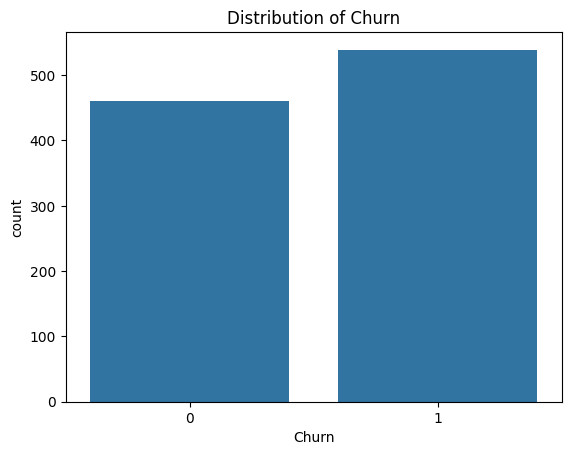

Churn
1    0.539
0    0.461
Name: proportion, dtype: float64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Churn", data=df)
plt.title("Distribution of Churn")
plt.show()
print(df["Churn"].value_counts(normalize=True))

In [12]:
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_cols= df.select_dtypes(include=["object"]).columns.tolist()
print("numerical columns", numerical_cols)
print("categorical_cols", categorical_cols)

numerical columns ['Subscription Length (Months)', 'Customer Satisfaction Score (1-10)', 'Daily Watch Time (Hours)', 'Engagement Rate (1-10)', 'Support Queries Logged', 'Age', 'Monthly Income ($)', 'Promotional Offers Used', 'Number of Profiles Created', 'Churn']
categorical_cols ['Device Used Most Often', 'Genre Preference', 'Region', 'Payment History (On-Time/Delayed)', 'Subscription Plan']


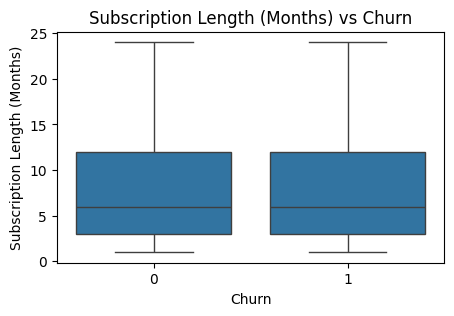

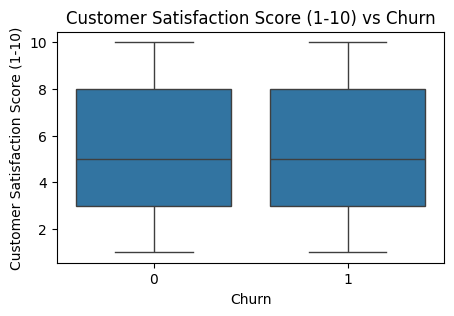

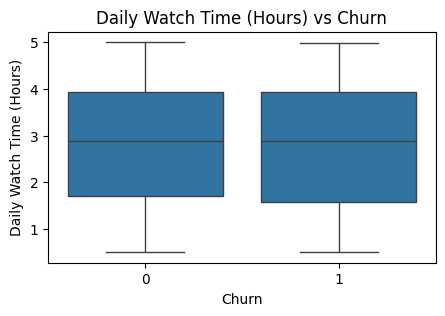

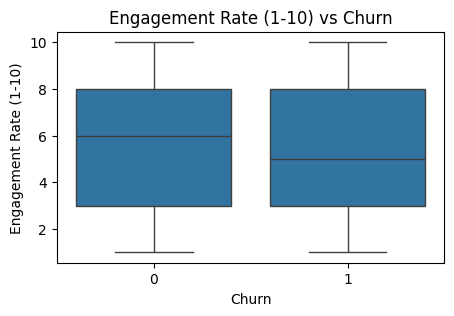

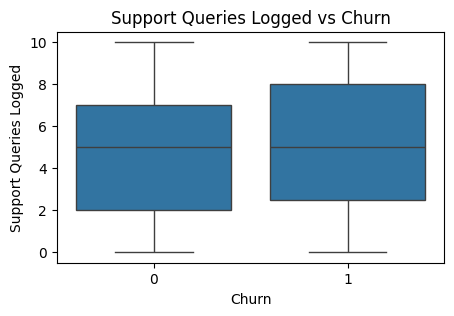

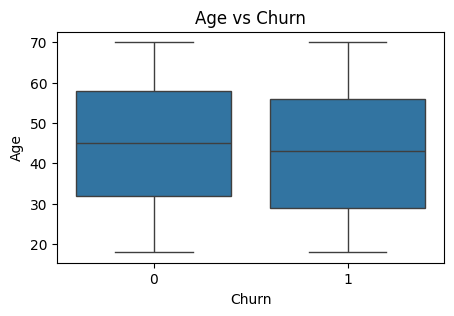

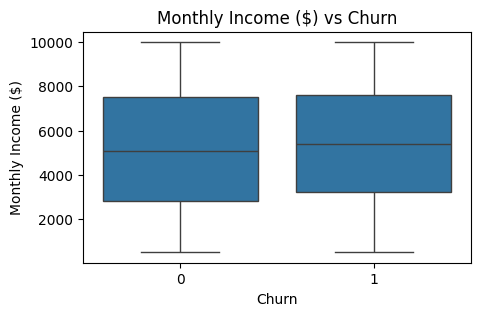

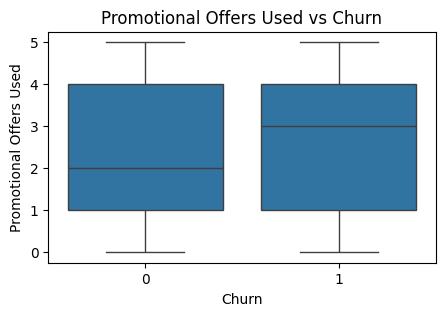

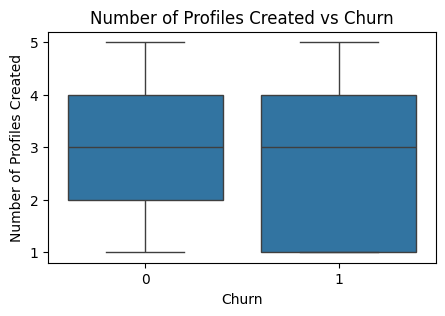

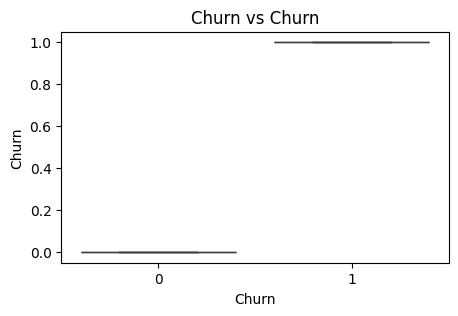

In [13]:
for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x="Churn", y =col , data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

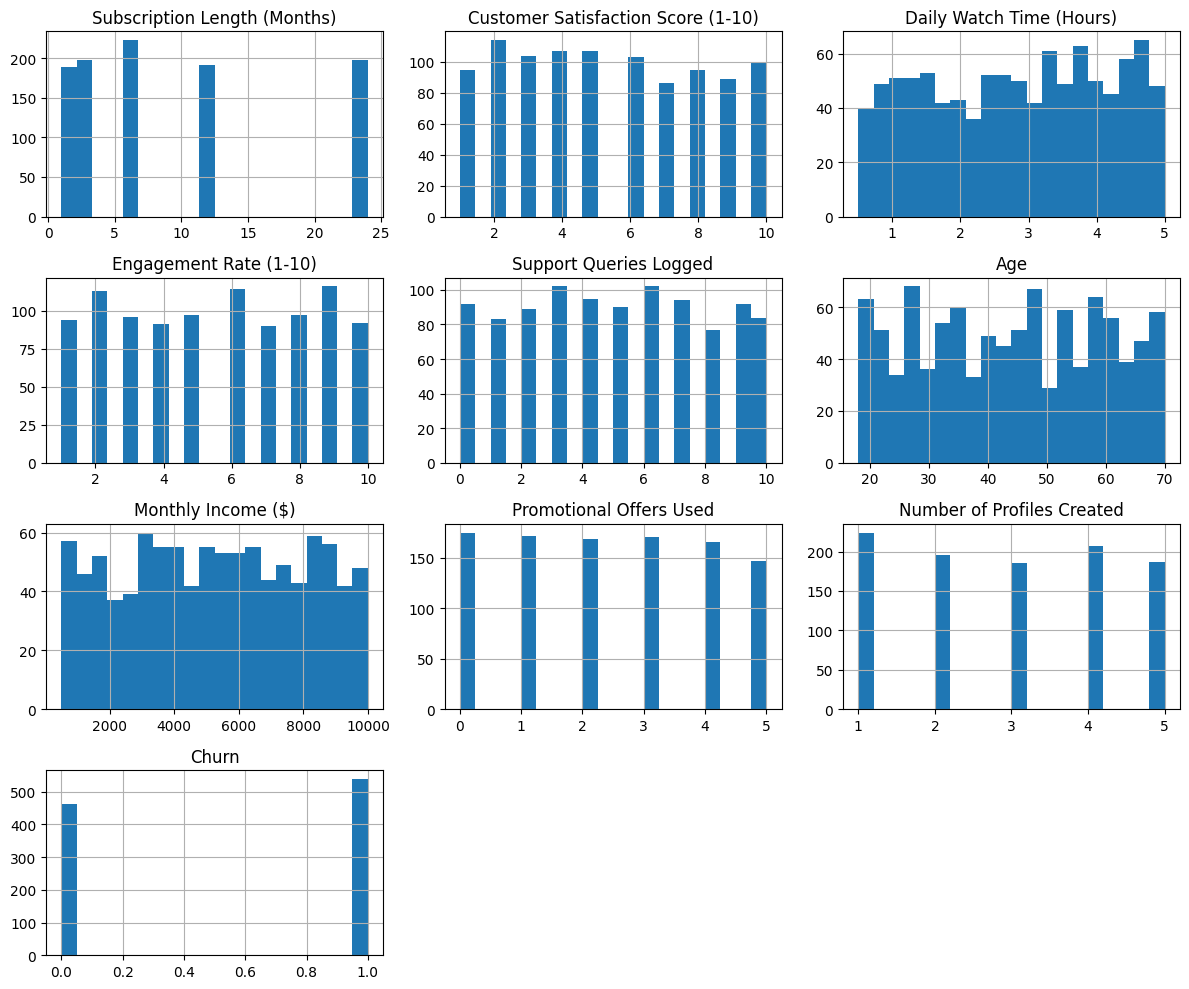

In [14]:
df[numerical_cols].hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

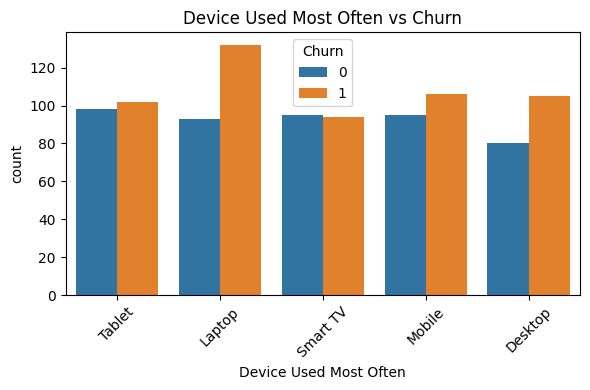

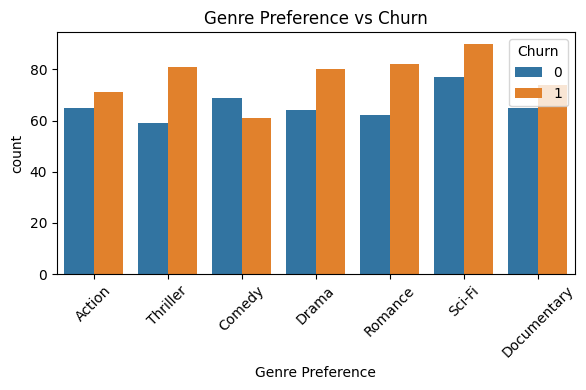

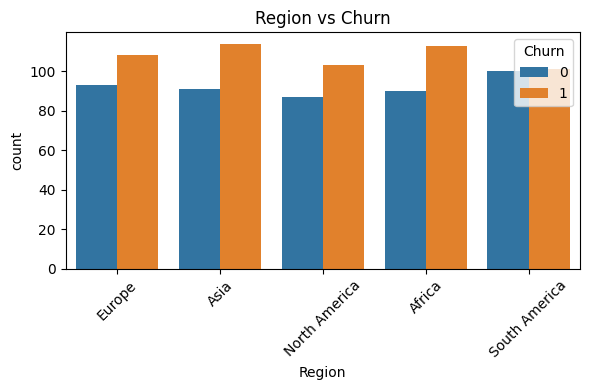

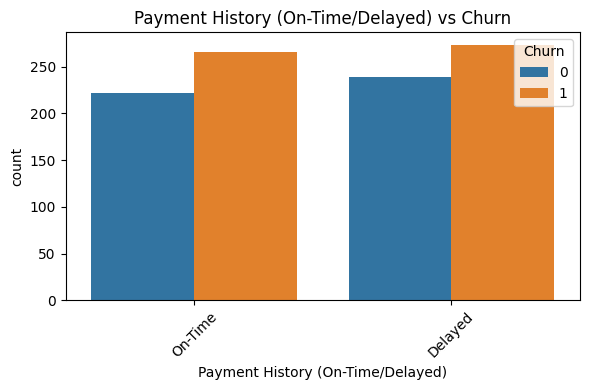

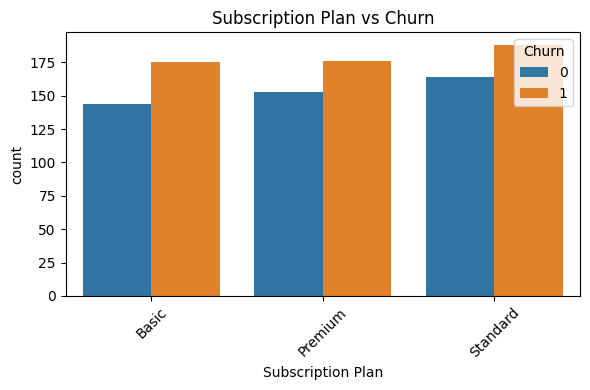

In [15]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="Churn", data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Churn")
    plt.tight_layout()
    plt.show()

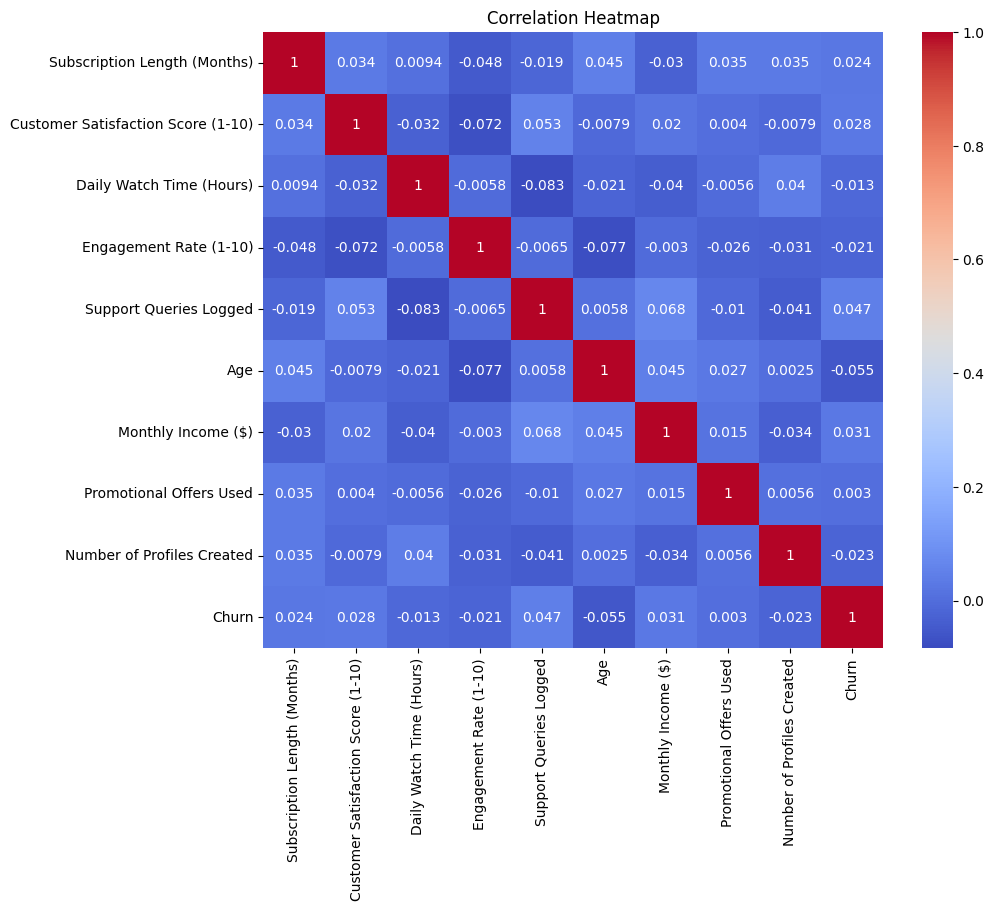

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 🔗 Correlation Analysis – Key Insight

The correlation heatmap shows that most numerical features have **very weak correlations** with each other and with the target variable (Churn).

### Key Observations
- Correlation values are close to **zero**, indicating weak linear relationships.
- No strong multicollinearity exists among features.
- No single feature strongly explains customer churn.

### Insight
This suggests that churn behavior is influenced by **multiple interacting factors** rather than a single variable. Therefore, a nonlinear ensemble model such as Random Forest is appropriate for capturing complex relationships in the data.

In [17]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print(X.shape, y.shape)

(1000, 14) (1000,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(800, 14) (200, 14)
(800,) (200,)


In [19]:
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: Index(['Subscription Length (Months)', 'Customer Satisfaction Score (1-10)',
       'Daily Watch Time (Hours)', 'Engagement Rate (1-10)',
       'Support Queries Logged', 'Age', 'Monthly Income ($)',
       'Promotional Offers Used', 'Number of Profiles Created'],
      dtype='object')
Categorical: Index(['Device Used Most Often', 'Genre Preference', 'Region',
       'Payment History (On-Time/Delayed)', 'Subscription Plan'],
      dtype='object')


In [20]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
rf_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42
    ))
])

In [22]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
y_pred_rf = rf_model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.525

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.41      0.44        92
           1       0.55      0.62      0.59       108

    accuracy                           0.53       200
   macro avg       0.52      0.52      0.51       200
weighted avg       0.52      0.53      0.52       200


Confusion Matrix:
 [[38 54]
 [41 67]]


In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [None, 5, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [100, 200, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [26]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}


In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))

Accuracy: 0.515
              precision    recall  f1-score   support

           0       0.45      0.25      0.32        92
           1       0.54      0.74      0.62       108

    accuracy                           0.52       200
   macro avg       0.49      0.50      0.47       200
weighted avg       0.50      0.52      0.48       200

[[23 69]
 [28 80]]


## 📈 Model Evaluation

The model was evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

### Results
- Accuracy: **52.5%**
- Recall for churn class: **0.62**

Although overall accuracy is moderate, higher recall for churn customers is valuable for business retention strategies.

## 💼 Business Insights

Key findings from the analysis:

- Churn is driven more by behavioral factors than demographics.
- Customers with higher support queries show higher churn tendency.
- Payment delays indicate increased churn risk.
- Subscription plan alone does not significantly influence churn.

Retention strategies should focus on improving customer experience and engagement.